![Imagen](https://docs.google.com/uc?export=download&id=1UteR1e3yMVJsFWAKunJ6_bxfTc5cflv8)



<h1><font color="#113D68" size=5>Análisis de entrenamiento</font></h1>



---

<a id="indice"></a>
<h2><font color="#004D7F" size=5>Índice</font></h2>

* [0. Contexto](#section0)
* [1. Historial de entrenamiento](#section1)
* [2. Visualizar el historial](#section2)

---
<a id="section0"></a>
# <font color="#004D7F" size=6> 0. Contexto</font>

En esta lección, aprenderemos a revisar y visualizar el rendimiento de los modelos a lo largo del tiempo durante el entrenamiento. Después de completar esta lección, sabrá:
* Cómo inspeccionar las métricas del historial.
* Cómo trazar métricas de Accuracy durante el entrenamiento.
* Cómo trazar métricas de pérdida durante el entrenamiento.

In [25]:
import tensorflow as tf
# Eliminar warning
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section1"></a>
# <font color="#004D7F" size=6>1. Historial de entrenamiento</font>

Keras registra métricas de entrenamiento para cada época. Esto incluye la pérdida y el Accuracy (para problemas de clasificación). El histórico se devuelve de las llamadas a la función `fit()` utilizada para entrenar el modelo.

Las métricas se almacenan en un diccionario en el histórico del objeto devuelto:
```Python
    # list all data in history
    print(history.history.keys())
```

Por ejemplo, para un modelo en un problema de clasificación se produce la siguiente lista:
```Python
    ['loss', 'accuracy', 'val_loss', 'val_accuracy']
```

Podemos utilizar los datos recopilados para crear gráficas que nos proporciona información sobre:
* La velocidad de convergencia sobre épocas (pendiente).
* Si el modelo puede haber convergido ya (meseta).
* Si el modelo tiene _overfitting_ (inflexión para la línea de validación).

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section2"></a>
# <font color="#004D7F" size=6>2. Visualizar el historial</font>

El ejemplo recopila el historial y crea dos gráficos:
1. Un gráfico de Accuracy durante épocas de entrenamiento.
2. Un gráfico de la pérdida (Loss) durante épocas de entrenamiento.

In [24]:
# Libreria para cargar nuestro drive
from google.colab import drive
# Cargamos nuestro drive en nuestro notebook
drive.mount('/content/drive')

MessageError: User cancelled dfs_ephemeral authorization

In [ ]:
#Mostrar el contenido del directorio donde se encuentran los datos
!ls 'DIRECCION EN DRIVE'

'/content/drive/My Drive/Curso_DL_2021B/DL_11_Multilayer Perceptron/clase/Datasets/pima-indians-diabetes.csv'


In [ ]:
import os
os.chdir('DIRECCION EN DRIVE')
!ls

In [70]:
#Ubicación archivo de datos
file_datos='/content/DLCV_12_Análisis de entrenamiento  con Keras/datos/pima-indians-diabetes.csv'

In [71]:
#Dataset
import pandas as pd
df = pd.read_csv(file_datos, header=None)
df

,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,627.00,50,1
1,1,85,66,29,0,26.6,351.00,31,0
2,8,183,64,0,0,23.3,672.00,32,1
3,1,89,66,23,94,28.1,167.00,21,0
4,0,137,40,35,168,43.1,2288.00,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,171.00,63,0
764,2,122,70,27,0,36.8,0.34,27,0
765,5,121,72,23,112,26.2,245.00,30,0
766,1,126,60,0,0,30.1,349.00,47,1


In [72]:
# Creación de muestras X,y
X = df.loc[:, 0:7]
y = df.loc[:, 8]

In [73]:
# Creación de X_train, X_test, y_train, y_test
from random import Random

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [74]:
# plicar  StandardScaler()
from sklearn.preprocessing import StandardScaler

scaler =  StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [75]:
# Fijar las semillas de los números aleatorios
import numpy as np
import random as python_random

np.random.seed(42)
python_random.seed(42)
tf.random.set_seed(42)

In [76]:
#Modelo en Keras
from keras.models import Sequential
from keras.layers import Dense, Input

modelo = Sequential()
modelo.add( Input( shape= (8, )) )
modelo.add( Dense(12 , activation='relu' )    )
modelo.add( Dense(8 , activation='relu' )    )
modelo.add( Dense(1 , activation='sigmoid' )    )

modelo.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

In [77]:

#Compilar el modelo
modelo.compile( loss='binary_crossentropy',
               optimizer='adam',
                metrics=['accuracy'])

In [78]:
# Fit del modelo
from sklearn import metrics


historial = modelo.fit(X_train, y_train, validation_split=0.2, epochs=70, batch_size=30)


Epoch 1/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.3968 - loss: 0.7683 - val_accuracy: 0.4715 - val_loss: 0.7646
Epoch 2/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4780 - loss: 0.7378 - val_accuracy: 0.5122 - val_loss: 0.7421
Epoch 3/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5158 - loss: 0.7134 - val_accuracy: 0.5528 - val_loss: 0.7232
Epoch 4/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5751 - loss: 0.6923 - val_accuracy: 0.6098 - val_loss: 0.7068
Epoch 5/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6100 - loss: 0.6726 - val_accuracy: 0.6504 - val_loss: 0.6919
Epoch 6/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6657 - loss: 0.6543 - val_accuracy: 0.6748 - val_loss: 0.6773
Epoch 7/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6900 - loss: 0.6371 - val_accuracy: 0.6748 - val_loss: 0.6625
Epoch 8/70
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7211 - loss: 0.6202 - val_accuracy: 0.6748 - val_loss

In [79]:
modelo.evaluate(X_test, y_test)[1]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7441 - loss: 0.5520


0.7532467246055603

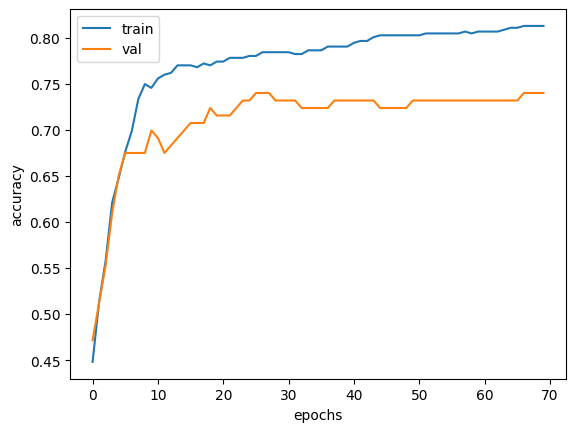

In [80]:
#Evaluación del modelo con accuracy
import matplotlib.pyplot as plt

plt.plot(historial.history['accuracy'])
plt.plot(historial.history['val_accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend(['train', 'val'])
plt.show()

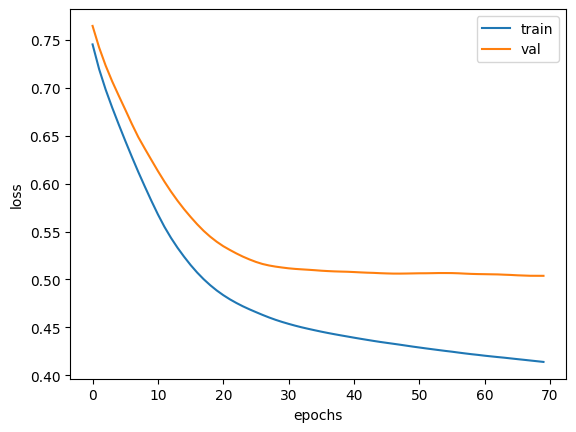

In [81]:
plt.plot(historial.history['loss'])
plt.plot(historial.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [82]:
# Historial de accuracy



In [83]:

# Historial de loss


# Interpretación de las curvas de *train* y *val* en Keras


### 1. Qué representan las curvas
* Train loss / accuracy: indican el error o precisión del modelo en los datos de entrenamiento.

* Validation loss / accuracy: muestran el desempeño en los datos de validación (no vistos por el modelo durante el entrenamiento).


### 2. Cómo interpretar las curvas

**A. Buen ajuste** (modelo generaliza bien). Ambas curvas bajan y se estabilizan cerca una de otra.  Indica que el modelo aprendió bien los patrones y generaliza correctamente.

**B. Sobreajuste** (overfitting). train_loss sigue bajando, pero val_loss deja de mejorar o incluso sube. El modelo memoriza los datos de entrenamiento y pierde capacidad de generalizar.

Soluciones posibles:
* Regularización (L2, Dropout, EarlyStopping)
* Aumentar los datos de entrenamiento
* Simplificar la red o reducir épocas


**C. Subajuste** (underfitting). Ambas curvas son altas y casi planas. El modelo no está aprendiendo lo suficiente.

Soluciones posibles:
* Aumentar número de épocas
* Usar un modelo más complejo
* Reducir la regularización
* Ajustar el learning rate


**D. Validación inestable**. val_loss o val_accuracy fluctúa mucho (sube y baja).

Puede deberse a:
* Pocos datos de validación
* Tasa de aprendizaje demasiado alta
* Tamaño de lote (batch size) pequeño

Soluciones posibles:
* Revisar la división de datos
* Reducir el learning rate
* Promediar resultados o usar EarlyStopping

###  Resumen visual

| Comportamiento               | `train_loss` | `val_loss` | Interpretación       |
| ---------------------------- | ------------ | ---------- | -------------------- |
| Ambas bajan y se estabilizan | ↓            | ↓          | Buen ajuste          |
| Train ↓, Val ↑               | ↓            | ↑          | Sobreajuste          |
| Ambas altas y planas         | ↑            | ↑          | Subajuste            |
| Validación irregular         | ↓            | ↑↓↑        | Validación inestable |
